# Labsense SQL Plots Between Two Timestamps

This notebook loads SQL data between `START_TS` and `END_TS` and reuses existing Labsense dashboard plotting functions.

Notes:
- It uses `Labsense_SQL.sql_helpers` for SQL environment and connection string setup.
- Existing dashboard plotting functions include their own internal "recent window" filters:
  - Electricity: last two years for daily trends and previous day for one subplot.
  - Water: last two months.
  - Fumehood: last 7 days.
- To see all expected plots, choose a timestamp window that overlaps those periods.

In [6]:
from pathlib import Path
import os
import sys

import pandas as pd
import pyodbc
from dotenv import load_dotenv
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    """Walk upward until the folder containing Labsense_SQL is found."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "Labsense_SQL").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing Labsense_SQL")


repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from Labsense_SQL import sql_helpers
from Labsense_SQL.consumption_dashboard import (
    CALCULATE_IDLE_POWER,
    calculate_idle_power,
    create_plots as create_consumption_plots,
)
from Labsense_SQL.Fumehood_dashboard import (
    FUMEHOOD_CALIBRATION,
    calculate_sash_percentage_open,
    get_display_label,
)
from Labsense_SQL.presence_utils import get_room_light_presence_data
from Labsense_SQL.water_dashboard import create_plots as create_water_plots

# Force-load the .env from Labsense_SQL
env_path = repo_root / "Labsense_SQL" / ".env"
if env_path.exists():
    load_dotenv(dotenv_path=env_path, override=True)
else:
    print(f"Warning: .env not found at {env_path}")

# Keep helper behavior as well (safe no-op if already loaded)
sql_helpers._load_sql_env()


def build_connection_string_with_driver_fallback() -> str:
    """Build SQL connection string using installed ODBC drivers."""
    sql_server = os.getenv("SQL_SERVER", "MSM-FPM-70203\\LABSENSE").strip()
    sql_database = os.getenv("SQL_DATABASE", "labsense").strip()
    sql_trusted = os.getenv("SQL_TRUSTED_CONNECTION", "yes").strip().lower()
    sql_encrypt = os.getenv("SQL_ENCRYPTION", "Optional").strip()
    sql_user = os.getenv("SQL_USER", "").strip()
    sql_password = os.getenv("SQL_PASSWORD", "").strip()

    available_drivers = pyodbc.drivers()
    preferred_driver = os.getenv("SQL_DRIVER", "ODBC Driver 18 for SQL Server").strip()
    driver_candidates = [
        preferred_driver,
        "ODBC Driver 18 for SQL Server",
        "ODBC Driver 17 for SQL Server",
        "SQL Server",
    ]
    selected_driver = next(
        (d for d in driver_candidates if d in available_drivers), None
    )

    if selected_driver is None:
        if not available_drivers:
            raise RuntimeError("No ODBC drivers found. Install SQL Server ODBC driver.")
        selected_driver = available_drivers[0]

    if sql_trusted == "yes":
        conn = (
            f"DRIVER={{{selected_driver}}};"
            f"SERVER={sql_server};"
            f"DATABASE={sql_database};"
            "Trusted_Connection=yes;"
            f"Encrypt={sql_encrypt}"
        )
    else:
        if not sql_user or not sql_password:
            raise ValueError(
                "SQL_USER and SQL_PASSWORD must be set when SQL_TRUSTED_CONNECTION is not 'yes'."
            )
        conn = (
            f"DRIVER={{{selected_driver}}};"
            f"SERVER={sql_server};"
            f"DATABASE={sql_database};"
            f"UID={sql_user};"
            f"PWD={sql_password};"
            f"Encrypt={sql_encrypt}"
        )

    print(f"Loaded .env: {env_path}")
    print(f"Using ODBC driver: {selected_driver}")
    print(f"SQL server/database: {sql_server} / {sql_database}")
    return conn


connection_string = build_connection_string_with_driver_fallback()

# --- User parameters ---
START_TS = pd.Timestamp("2026-05-11 00:00:00")
END_TS = pd.Timestamp("2026-05-15 23:59:59")
PRESENCE_LAB_ID = 1
PRESENCE_SUBLAB_ID = 3

if END_TS <= START_TS:
    raise ValueError("END_TS must be later than START_TS")

PLOT_DIR = repo_root / "plots" / f"notebook_{START_TS:%Y%m%d_%H%M}_{END_TS:%Y%m%d_%H%M}"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using SQL window: {START_TS} -> {END_TS}")
print(f"Plot output dir: {PLOT_DIR}")

Loaded .env: C:\Users\fpm-admin\src\labsense\Labsense_SQL\.env
Using ODBC driver: ODBC Driver 18 for SQL Server
SQL server/database: MSM-FPM-70203\LABSENSE / labsense
Using SQL window: 2026-05-11 00:00:00 -> 2026-05-15 23:59:59
Plot output dir: C:\Users\fpm-admin\src\labsense\plots\notebook_20260511_0000_20260515_2359


In [7]:
def read_sql_df(
    connection, query: str, start_ts: pd.Timestamp, end_ts: pd.Timestamp
) -> pd.DataFrame:
    """Run a bounded SQL query and coerce Timestamp/Datestamp columns to datetime."""
    df = pd.read_sql(
        query,
        connection,
        params=[start_ts.to_pydatetime(), end_ts.to_pydatetime()],
    )
    if "Timestamp" in df.columns:
        df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    if "Datestamp" in df.columns:
        df["Datestamp"] = pd.to_datetime(df["Datestamp"])
    return df


with pyodbc.connect(connection_string) as conn:
    df_elec_daily = read_sql_df(
        conn,
        """
        SELECT id, Esum, Datestamp
        FROM dbo.elecDaily
        WHERE Datestamp >= ? AND Datestamp <= ?
        ORDER BY Datestamp ASC
        """,
        START_TS,
        END_TS,
    )

    df_elec_minute = read_sql_df(
        conn,
        """
        SELECT id, EnergyValue, Timestamp
        FROM dbo.elecMinute
        WHERE Timestamp >= ? AND Timestamp <= ?
        ORDER BY Timestamp ASC
        """,
        START_TS,
        END_TS,
    )

    df_fumehood = read_sql_df(
        conn,
        """
        SELECT id, LabId, SubLabId, Distance, Light, Airflow, Timestamp
        FROM dbo.fumehood
        WHERE Timestamp >= ? AND Timestamp <= ?
        ORDER BY Timestamp ASC
        """,
        START_TS,
        END_TS,
    )

    df_water = read_sql_df(
        conn,
        """
        SELECT id, LabId, SublabId, Water, Timestamp
        FROM dbo.water
        WHERE Timestamp >= ? AND Timestamp <= ?
        ORDER BY Timestamp ASC
        """,
        START_TS,
        END_TS,
    )

# Presence series used by electricity previous-day subplot logic
light_for_presence = df_fumehood[
    (df_fumehood["LabId"] == PRESENCE_LAB_ID)
    & (df_fumehood["SubLabId"] == PRESENCE_SUBLAB_ID)
][["Light", "Timestamp"]].copy()

presence_df = get_room_light_presence_data(
    light_for_presence,
    lab_id=PRESENCE_LAB_ID,
    sublab_id=PRESENCE_SUBLAB_ID,
)

display(
    pd.DataFrame(
        {
            "dataset": ["elecDaily", "elecMinute", "fumehood", "water", "presence"],
            "rows": [
                len(df_elec_daily),
                len(df_elec_minute),
                len(df_fumehood),
                len(df_water),
                0 if presence_df is None else len(presence_df),
            ],
        }
    )
)

C:\Users\fpm-admin\AppData\Local\Temp\ipykernel_25424\436330131.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(
C:\Users\fpm-admin\AppData\Local\Temp\ipykernel_25424\436330131.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(
C:\Users\fpm-admin\AppData\Local\Temp\ipykernel_25424\436330131.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(
C:\Users\fpm-admin\AppData\Local\Temp\ipykernel_25424\436330131.py:5: UserWarning: pandas only supports SQLAlchemy connectable 

,dataset,rows
0,elecDaily,5
1,elecMinute,7200
2,fumehood,10183
3,water,114
4,presence,10183


In [8]:
idle_power_kw = 0.0
if CALCULATE_IDLE_POWER and not df_elec_minute.empty:
    idle_power_kw = calculate_idle_power(df_elec_minute)

consumption_plot_files = create_consumption_plots(
    df=df_elec_daily,
    plot_dir=PLOT_DIR,
    df_granular=df_elec_minute,
    idle_power_kw=idle_power_kw,
    presence_df=presence_df,
)

water_plot_files = create_water_plots(
    df=df_water,
    plot_dir=PLOT_DIR,
)

# Custom fumehood plots (not using dashboard helper plots)
fumehood_plot_files = {}
fumehood_raw_plot_files = {}
if df_fumehood.empty:
    print("No fumehood records in selected range")
else:
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    excluded_distance_ranges = [
        {"min": 530, "max": 567},
        {"min": 265, "max": 290},
        {"min": 365, "max": 385},
    ]

    def in_excluded_distance_range(distance: float) -> bool:
        return any(
            distance_range["min"] <= distance <= distance_range["max"]
            for distance_range in excluded_distance_ranges
        )

    def shade_sash_open_intervals(ax_list, open_df: pd.DataFrame):
        if open_df.empty:
            return

        open_df = open_df.sort_values(by=["Timestamp"]).reset_index(drop=True).copy()
        time_gaps = open_df["Timestamp"].diff().dropna()
        if time_gaps.empty or pd.isna(time_gaps.median()):
            typical_gap = pd.Timedelta(minutes=5)
        else:
            typical_gap = pd.Timedelta(time_gaps.median())
        gap_threshold = max(pd.Timedelta(minutes=30), typical_gap * 3)

        i = 0
        while i < len(open_df):
            if not bool(open_df.loc[i, "SashOpen"]):
                i += 1
                continue

            start = open_df.loc[i, "Timestamp"]
            j = i
            while j + 1 < len(open_df):
                next_gap = open_df.loc[j + 1, "Timestamp"] - open_df.loc[j, "Timestamp"]
                if not bool(open_df.loc[j + 1, "SashOpen"]) or next_gap > gap_threshold:
                    break
                j += 1

            end = open_df.loc[j, "Timestamp"] + typical_gap
            for ax in ax_list:
                ax.axvspan(start, end, color="#2ecc71", alpha=0.18, zorder=0)
            i = j + 1

    combos = (
        df_fumehood[["LabId", "SubLabId"]]
        .drop_duplicates()
        .sort_values(by=["LabId", "SubLabId"])
    )

    all_days = pd.Index(
        df_fumehood["Timestamp"].dt.normalize().drop_duplicates().sort_values()
    )

    for _, combo in combos.iterrows():
        lab_id = int(combo["LabId"])
        sublab_id = int(combo["SubLabId"])
        key = (lab_id, sublab_id)

        hood_df = df_fumehood[
            (df_fumehood["LabId"] == lab_id) & (df_fumehood["SubLabId"] == sublab_id)
        ].sort_values(by=["Timestamp"])

        if hood_df.empty:
            continue

        for day_start in all_days:
            day_end = day_start + pd.Timedelta(days=1)
            day_hood_df = hood_df[
                (hood_df["Timestamp"] >= day_start) & (hood_df["Timestamp"] < day_end)
            ].copy()

            if day_hood_df.empty:
                continue

            # Apply distance exclusions before plotting sash height.
            sash_df = day_hood_df[
                ~day_hood_df["Distance"].apply(in_excluded_distance_range)
            ].copy()

            # Keep only valid positive light values for plotting.
            light_values = pd.to_numeric(day_hood_df["Light"], errors="coerce")
            light_plot_df = day_hood_df[light_values > 0].copy()

            fig, (ax_sash, ax_light) = plt.subplots(
                2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"hspace": 0.2}
            )

            if key in FUMEHOOD_CALIBRATION and not sash_df.empty:
                sash_series = sash_df["Distance"].apply(
                    lambda d: calculate_sash_percentage_open(d, lab_id, sublab_id)
                )
                sash_mask = sash_series.notna()
                ax_sash.scatter(
                    sash_df.loc[sash_mask, "Timestamp"],
                    sash_series.loc[sash_mask],
                    color="#1f77b4",
                    s=14,
                    alpha=0.8,
                )
                ax_sash.set_ylabel("Sash Opening (%)")
                ax_sash.set_ylim(0, 100)
                ax_sash.set_title(
                    f"{get_display_label(lab_id, sublab_id)}: Sash Opening ({day_start:%Y-%m-%d})"
                )

                open_df = sash_df.loc[sash_mask, ["Timestamp"]].copy()
                open_df["SashOpen"] = sash_series.loc[sash_mask] > 10.0
                shade_sash_open_intervals([ax_sash, ax_light], open_df)
            elif not sash_df.empty:
                ax_sash.scatter(
                    sash_df["Timestamp"],
                    sash_df["Distance"],
                    color="#1f77b4",
                    s=14,
                    alpha=0.8,
                )
                ax_sash.set_ylabel("Sash Opening (mm)")
                ax_sash.set_title(
                    f"{get_display_label(lab_id, sublab_id)}: Sash Opening (raw distance, {day_start:%Y-%m-%d})"
                )
            else:
                ax_sash.set_ylabel("Sash Opening")
                ax_sash.set_title(
                    f"{get_display_label(lab_id, sublab_id)}: Sash Opening (all values excluded, {day_start:%Y-%m-%d})"
                )
            ax_sash.grid(True, alpha=0.3)

            ax_light.scatter(
                light_plot_df["Timestamp"],
                light_plot_df["Light"],
                color="#ff7f0e",
                s=14,
                alpha=0.8,
            )
            ax_light.set_ylabel("Light (lux)")
            ax_light.set_xlabel("Timestamp")
            ax_light.set_title(
                f"{get_display_label(lab_id, sublab_id)}: Light Level ({day_start:%Y-%m-%d})"
            )
            ax_light.grid(True, alpha=0.3)

            ax_light.xaxis.set_major_locator(mdates.HourLocator(interval=1))
            ax_light.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
            plt.xticks(rotation=30, ha="right")
            fig.tight_layout()

            out_name = (
                f"fumehood_custom_lab{lab_id}_sublab{sublab_id}_{day_start:%Y%m%d}.png"
            )
            fig.savefig(PLOT_DIR / out_name, dpi=150, bbox_inches="tight")
            plt.close(fig)
            fumehood_plot_files[(lab_id, sublab_id, pd.Timestamp(day_start).date())] = (
                out_name
            )

            # Additional raw distance-only plot (no exclusions).
            fig_raw, ax_raw = plt.subplots(figsize=(12, 4.5))
            ax_raw.scatter(
                day_hood_df["Timestamp"],
                day_hood_df["Distance"],
                color="#2c3e50",
                s=14,
                alpha=0.8,
            )
            ax_raw.set_ylabel("Raw Distance (mm)")
            ax_raw.set_xlabel("Timestamp")
            ax_raw.set_title(
                f"{get_display_label(lab_id, sublab_id)}: Raw Distance ({day_start:%Y-%m-%d})"
            )
            ax_raw.grid(True, alpha=0.3)
            ax_raw.xaxis.set_major_locator(mdates.HourLocator(interval=1))
            ax_raw.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
            plt.xticks(rotation=30, ha="right")
            fig_raw.tight_layout()

            raw_out_name = (
                f"fumehood_raw_lab{lab_id}_sublab{sublab_id}_{day_start:%Y%m%d}.png"
            )
            fig_raw.savefig(PLOT_DIR / raw_out_name, dpi=150, bbox_inches="tight")
            plt.close(fig_raw)
            fumehood_raw_plot_files[
                (lab_id, sublab_id, pd.Timestamp(day_start).date())
            ] = raw_out_name

print("Consumption plots:", sorted(consumption_plot_files.keys()))
print("Water plots:", len(water_plot_files))
print("Fumehood custom plots:", len(fumehood_plot_files))
print("Fumehood raw plots:", len(fumehood_raw_plot_files))

Calculated idle power: 1.790 kW (from 1200 data points)
Created plot: C:\Users\fpm-admin\src\labsense\plots\notebook_20260511_0000_20260515_2359\electricity_consumption_trends.png
Created plot: C:\Users\fpm-admin\src\labsense\plots\notebook_20260511_0000_20260515_2359\electricity_consumption_2026-05-11.png
Created plot: C:\Users\fpm-admin\src\labsense\plots\notebook_20260511_0000_20260515_2359\electricity_consumption_2026-05-12.png
Created plot: C:\Users\fpm-admin\src\labsense\plots\notebook_20260511_0000_20260515_2359\electricity_consumption_2026-05-13.png
Created plot: C:\Users\fpm-admin\src\labsense\plots\notebook_20260511_0000_20260515_2359\electricity_consumption_2026-05-14.png
Created plot: C:\Users\fpm-admin\src\labsense\plots\notebook_20260511_0000_20260515_2359\electricity_consumption_2026-05-15.png
Idle energy percentage: 108.2%
Active energy percentage: 0.0%


C:\Users\fpm-admin\AppData\Local\Temp\ipykernel_25424\3524529891.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
C:\Users\fpm-admin\AppData\Local\Temp\ipykernel_25424\3524529891.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
C:\Users\fpm-admin\AppData\Local\Temp\ipykernel_25424\3524529891.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
C:\Users\fpm-admin\AppData\Local\Temp\ipykernel_25424\3524529891.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
C:\Users\fpm-admin\AppData\Local\Temp\ipykernel_25424\3524529891.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might 

Consumption plots: ['active_energy_kwh', 'active_percentage', 'daily', 'granular_20260511', 'granular_20260512', 'granular_20260513', 'granular_20260514', 'granular_20260515', 'idle_percentage', 'idle_power_kw']
Water plots: 1
Fumehood custom plots: 5
Fumehood raw plots: 5


C:\Users\fpm-admin\src\labsense\Labsense_SQL\ChemInventory_dashboard.py:121: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


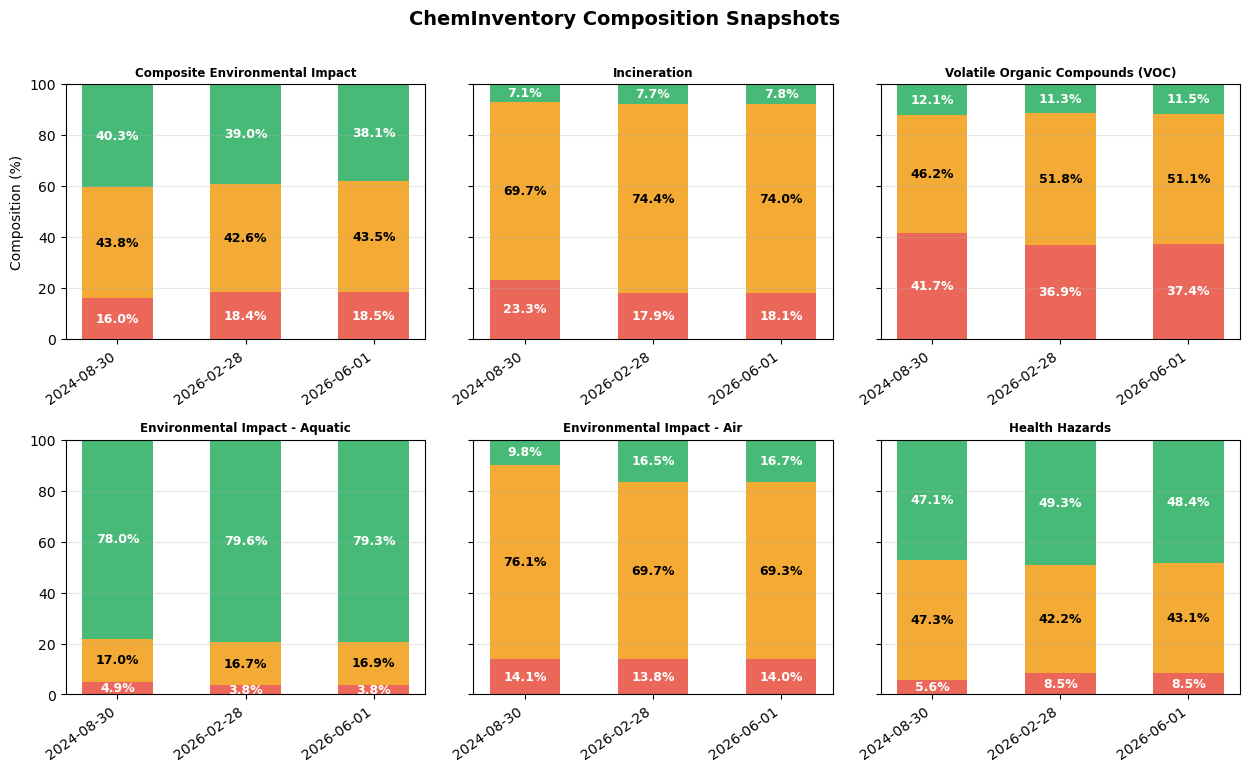

Saved: C:\Users\fpm-admin\src\labsense\plots\cheminventory_snapshots\cheminventory_snapshots.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from typing import Optional
from Labsense_SQL.ChemInventory_dashboard import (
    CATEGORIES,
    CATEGORY_DISPLAY_NAMES,
    fetch_all_data as fetch_cheminventory_all_data,
)

# --- User parameters: list the specific snapshot dates to compare ---
CHEM_SNAPSHOT_DATES = [
    pd.Timestamp("2024-08-30"),
    pd.Timestamp("2026-02-28"),
    pd.Timestamp("2026-06-01"),
]

# Max gap (days) to search for the nearest record around each target date
CHEM_DATE_TOLERANCE_DAYS = 1

CHEM_PLOT_DIR = repo_root / "plots" / "cheminventory_snapshots"
CHEM_PLOT_DIR.mkdir(parents=True, exist_ok=True)

raw_cheminventory_data = fetch_cheminventory_all_data(connection_string)


def nearest_record(
    df: pd.DataFrame, target: pd.Timestamp, tol_days: int
) -> Optional[dict]:
    """Return % composition for the record in df closest to target (within tol_days)."""
    df = df.copy()
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
    df = df.dropna(subset=["Timestamp"])
    df["_dist"] = (df["Timestamp"] - target).abs()
    nearest = df.nsmallest(1, "_dist")
    if nearest.empty or nearest.iloc[0]["_dist"] > pd.Timedelta(days=tol_days):
        return None
    row = nearest.iloc[0]
    total = row["RedVol"] + row["YellowVol"] + row["GreenVol"]
    safe_total = total if total != 0 else 1
    return {
        "date": row["Timestamp"],
        "red_pct": row["RedVol"] / safe_total * 100,
        "yellow_pct": row["YellowVol"] / safe_total * 100,
        "green_pct": row["GreenVol"] / safe_total * 100,
    }


# Build snapshot table: {category: [record_or_None, ...]}
snapshots = {}
for cat in CATEGORIES:
    cat_df = raw_cheminventory_data.get(cat)
    if cat_df is None or cat_df.empty:
        snapshots[cat] = [None] * len(CHEM_SNAPSHOT_DATES)
        continue
    snapshots[cat] = [
        nearest_record(cat_df, ts, CHEM_DATE_TOLERANCE_DAYS)
        for ts in CHEM_SNAPSHOT_DATES
    ]

# --- 3x2 figure: one subplot per category ---
n_cats = len(CATEGORIES)
n_dates = len(CHEM_SNAPSHOT_DATES)
bar_width = 0.55
x = list(range(n_dates))
date_labels = [ts.strftime("%Y-%m-%d") for ts in CHEM_SNAPSHOT_DATES]

ncols = 3
nrows = 2
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.2 * ncols, 3.8 * nrows),
    sharey=True,
    squeeze=False,
)
axes = axes.ravel()
fig.suptitle(
    "ChemInventory Composition Snapshots", fontsize=14, fontweight="bold", y=1.01
)

for ax, cat in zip(axes, CATEGORIES):
    records = snapshots[cat]
    reds = [r["red_pct"] if r else 0.0 for r in records]
    yellows = [r["yellow_pct"] if r else 0.0 for r in records]
    greens = [r["green_pct"] if r else 0.0 for r in records]
    bottoms_yellow = reds
    bottoms_green = [r + y for r, y in zip(reds, yellows)]

    ax.bar(x, reds, width=bar_width, color="#e74c3c", alpha=0.85)
    ax.bar(
        x,
        yellows,
        width=bar_width,
        color="#f39c12",
        alpha=0.85,
        bottom=bottoms_yellow,
    )
    ax.bar(
        x,
        greens,
        width=bar_width,
        color="#27ae60",
        alpha=0.85,
        bottom=bottoms_green,
    )

    # Add percent labels inside each stacked section.
    for i, (red, yellow, green) in enumerate(zip(reds, yellows, greens)):
        if red > 0:
            ax.text(
                i,
                red / 2,
                f"{red:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                color="white",
                fontweight="bold",
            )
        if yellow > 0:
            ax.text(
                i,
                red + (yellow / 2),
                f"{yellow:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                color="black",
                fontweight="bold",
            )
        if green > 0:
            ax.text(
                i,
                red + yellow + (green / 2),
                f"{green:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                color="white",
                fontweight="bold",
            )

    ax.set_title(
        CATEGORY_DISPLAY_NAMES.get(cat, cat),
        fontsize=8.5,
        fontweight="bold",
        wrap=True,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(date_labels, rotation=35, ha="right", fontsize=10)
    ax.set_ylim(0, 100)
    ax.grid(True, axis="y", alpha=0.3)
    ax.tick_params(axis="y", labelsize=10)

# Hide any unused subplot slots (if categories < 6).
for ax in axes[n_cats:]:
    ax.axis("off")

axes[0].set_ylabel("Composition (%)", fontsize=10)

fig.tight_layout()

out_path = CHEM_PLOT_DIR / "cheminventory_snapshots.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

In [ ]:
generated_pngs = sorted(PLOT_DIR.glob("*.png"))
summary_df = pd.DataFrame(
    {
        "plot_file": [p.name for p in generated_pngs],
        "size_kb": [round(p.stat().st_size / 1024, 1) for p in generated_pngs],
    }
)

display(summary_df)

if not summary_df.empty:
    print(f"Generated {len(summary_df)} plot image(s) in {PLOT_DIR}")
else:
    print(
        "No plots were generated. Verify timestamp window and dashboard internal lookback windows."
    )

: 

: 

: 